In [1]:
from training import *
import pandas as pd

In [2]:
df = pd.read_csv("/Users/filipporonzino/Desktop/thesis/bsc-thesis/bsc-thesis/data/pricing_data.csv")

In [ ]:
# 1. Run your experiment with data saving enabled
results = run_option_pricing_example(df, save_data=True)

Prepared 298 valid option configurations from market data
Training set: 178 options, Test set: 120 options
Generating Monte Carlo prices for comparison...
Processing option 1/120
Processing option 2/120
Processing option 3/120
Processing option 4/120
Processing option 5/120
Processing option 6/120
Processing option 7/120
Processing option 8/120
Processing option 9/120
Processing option 10/120
Processing option 11/120
Processing option 12/120
Processing option 13/120
Processing option 14/120
Processing option 15/120
Processing option 16/120
Processing option 17/120
Processing option 18/120
Processing option 19/120
Processing option 20/120
Processing option 21/120
Processing option 22/120
Processing option 23/120
Processing option 24/120
Processing option 25/120
Processing option 26/120
Processing option 27/120
Processing option 28/120
Processing option 29/120
Processing option 30/120
Processing option 31/120
Processing option 32/120
Processing option 33/120
Processing option 34/120
Proc

Loaded data from processed_data/option_data_historical_data.csv
Shape: (10855, 19) - 10855 rows, 19 columns

First few rows:
           id()       SECURITY_DES EXERCISE_TYPE   EXPIRE_DT PUT_CALL  \
0  BBG01LB3KJY2  G9F6C 69.5 Comdty      European  2026-01-30     Call   
1  BBG01LB3KJY2  G9F6C 69.5 Comdty      European  2026-01-30     Call   
2  BBG01LB3KJY2  G9F6C 69.5 Comdty      European  2026-01-30     Call   
3  BBG01LB3KJY2  G9F6C 69.5 Comdty      European  2026-01-30     Call   
4  BBG01LB3KJY2  G9F6C 69.5 Comdty      European  2026-01-30     Call   

   STRIKE_PX       TICKER        Date  OPT_PX  HIST_PUT_IMP_VOL  \
0       69.5  G9F6 Comdty  2024-09-11    5.43             29.77   
1       69.5  G9F6 Comdty  2024-09-19    6.74             28.12   
2       69.5  G9F6 Comdty  2024-09-20    6.65             27.79   
3       69.5  G9F6 Comdty  2024-10-01    6.93             30.42   
4       69.5  G9F6 Comdty  2024-10-02    7.11             32.30   

   VOLATILITY_30D  HIST_CALL_IMP_

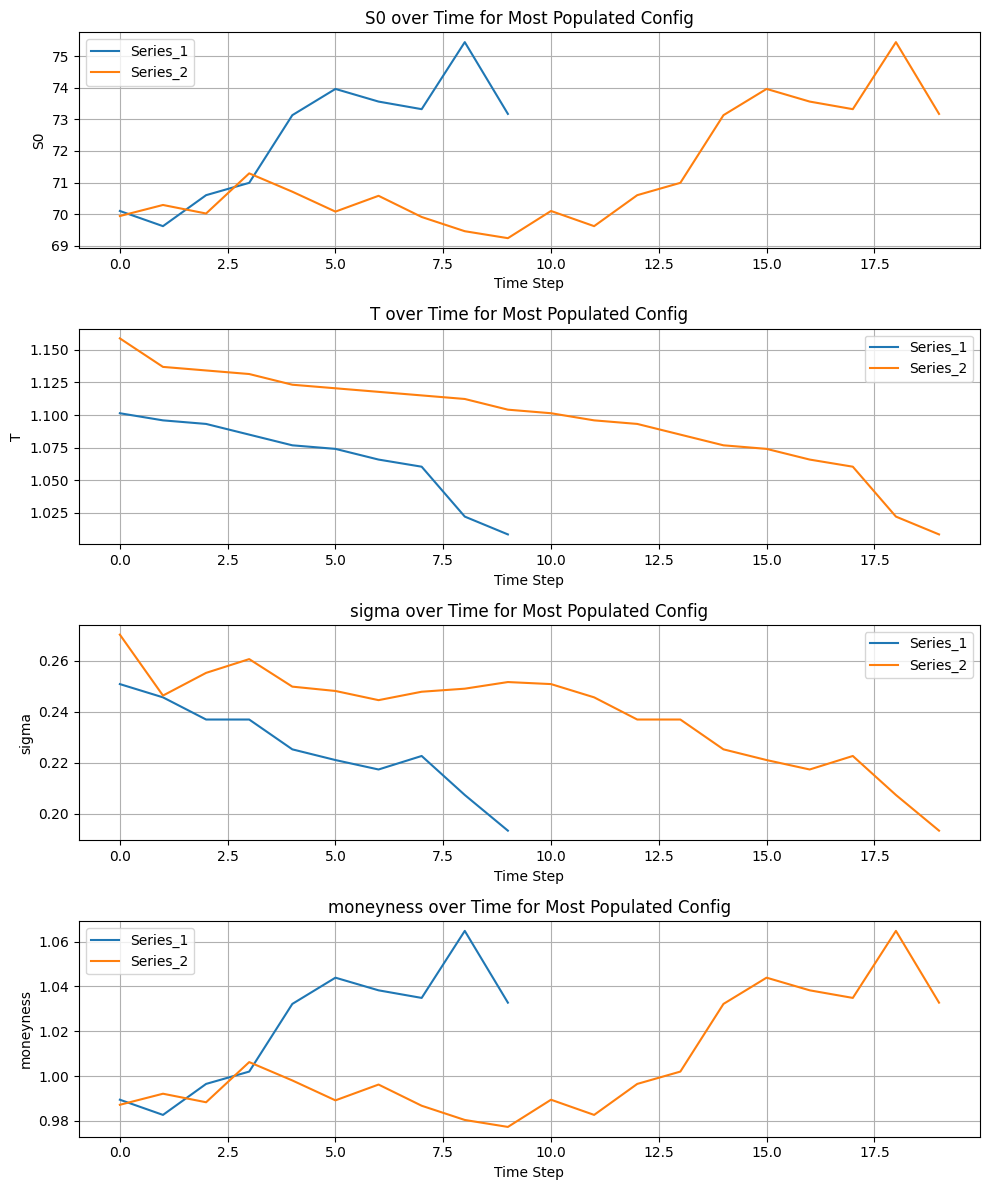

NameError: name 'results' is not defined

In [ ]:
# 2. Inspect the saved historical data
historical_df = inspect_saved_data("processed_data/option_data_historical_data.csv")

# 3. Inspect option configurations
options_df = inspect_saved_data("processed_data/option_data_all_options.csv")

# 4. Compare LSTM input time series samples
lstm_samples = [
    "processed_data/lstm_input_simple_lstm.csv",
    "processed_data/lstm_input_deep_lstm.csv"
]
compare_time_series_data(lstm_samples, key_columns=['S0', 'T', 'sigma', 'moneyness'])

# 5. Compare LSTM and MC predictions 
# First save a combined results file with both LSTM and MC prices

# Load test options
test_df = pd.read_csv("processed_data/option_data_test_options.csv")

# Add LSTM predicted prices for a specific model (e.g., Simple LSTM)
model_name = "Simple LSTM"
lstm_prices = results['lstm_results'][model_name]['prices']
test_df['lstm_price'] = lstm_prices

# Save the combined results
test_df.to_csv("processed_data/combined_test_results.csv", index=False)

# Now compare the prices
comparison = compare_lstm_mc_predictions("processed_data/combined_test_results.csv")

Results loaded from lstm_evaluation_results.pkl
Showing 30 options out of 120 total options


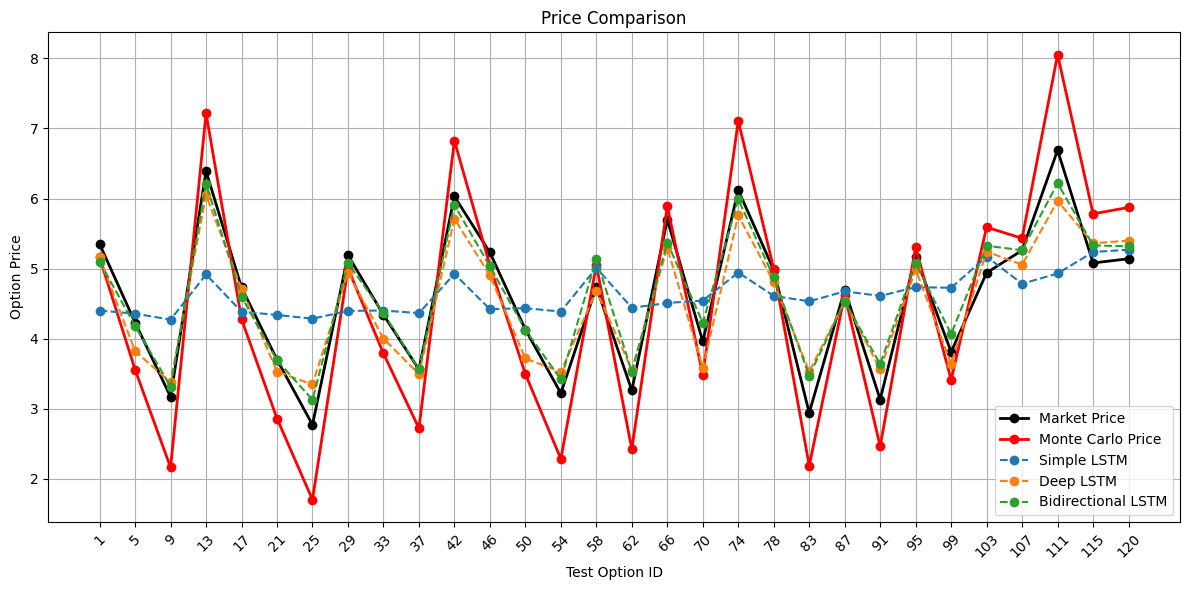

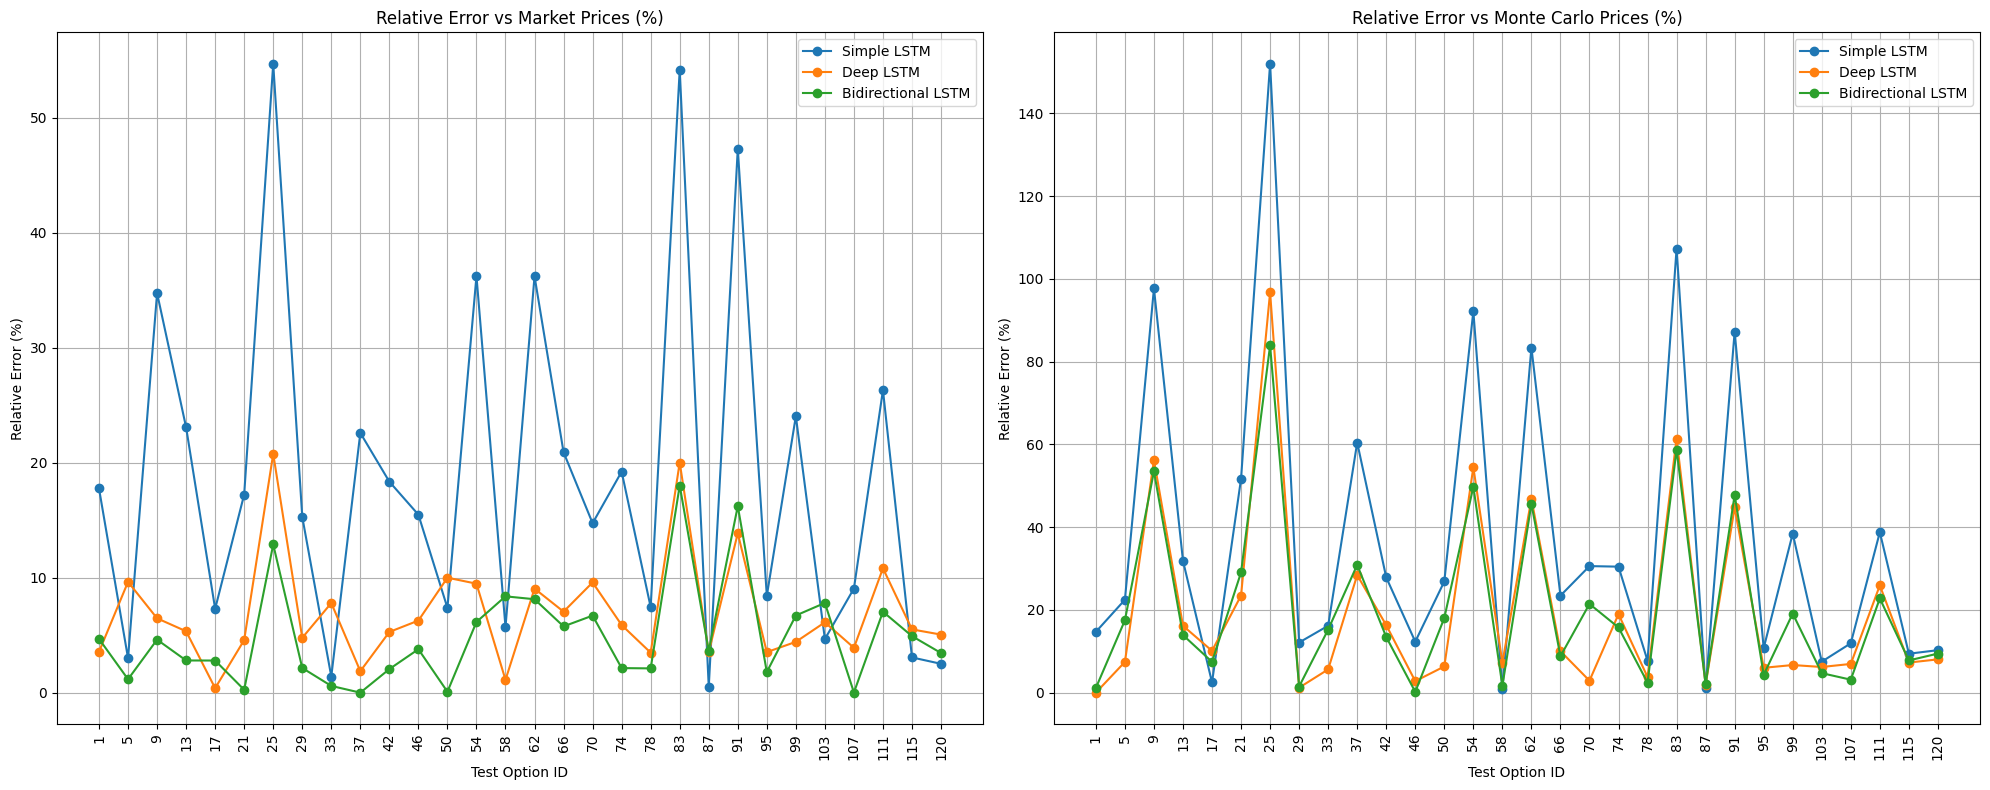

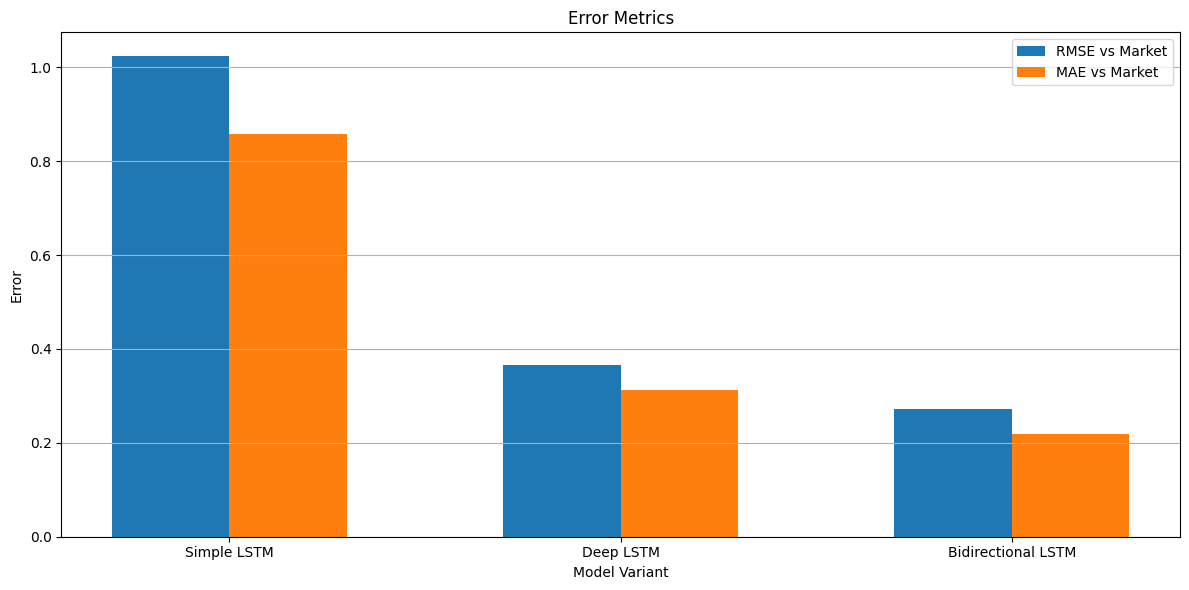

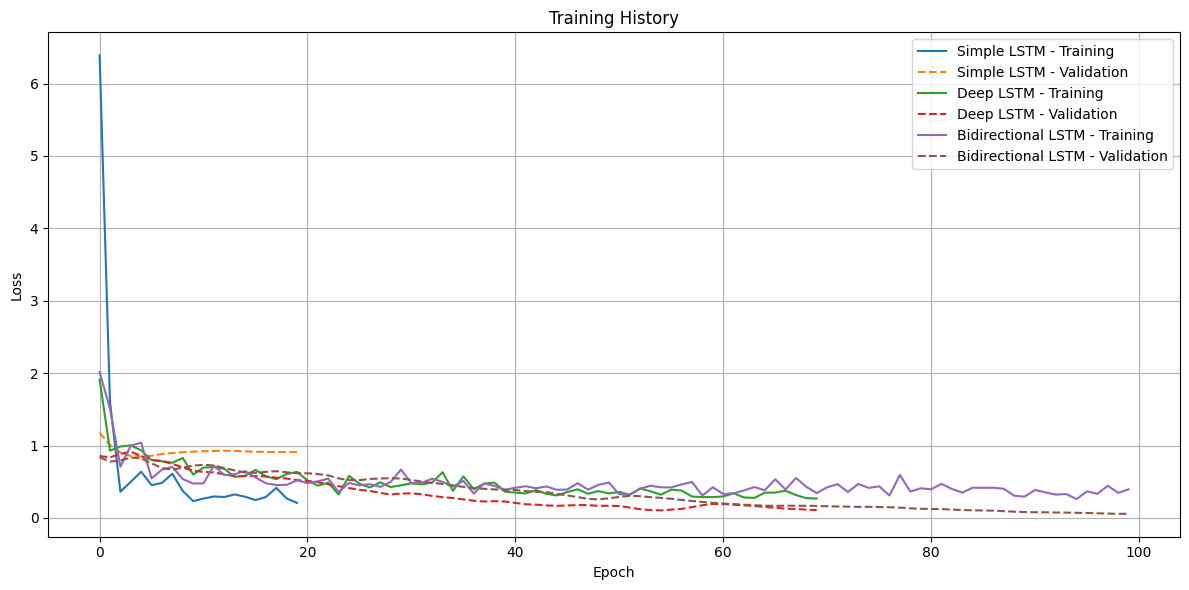

{'train_configs': [{'name': 'G9F6C 69.5 Comdty',
   'S0': 73.16999816894531,
   'K': 69.5,
   'T': 1.008219178082192,
   'r': 0.0452799987792968,
   'sigma': 0.1934,
   'option_type': 'arithmetic'},
  {'name': 'G9F6C 71.1 Comdty',
   'S0': 73.16999816894531,
   'K': 71.1,
   'T': 1.008219178082192,
   'r': 0.0452799987792968,
   'sigma': 0.1934,
   'option_type': 'arithmetic'},
  {'name': 'G9F6C 71.85 Comdty',
   'S0': 73.16999816894531,
   'K': 71.85,
   'T': 1.008219178082192,
   'r': 0.0452799987792968,
   'sigma': 0.1934,
   'option_type': 'arithmetic'},
  {'name': 'G9F6C 72.2 Comdty',
   'S0': 73.16999816894531,
   'K': 72.2,
   'T': 1.008219178082192,
   'r': 0.0452799987792968,
   'sigma': 0.1934,
   'option_type': 'arithmetic'},
  {'name': 'G9F6C 72.67 Comdty',
   'S0': 73.16999816894531,
   'K': 72.67,
   'T': 1.008219178082192,
   'r': 0.0452799987792968,
   'sigma': 0.1934,
   'option_type': 'arithmetic'},
  {'name': 'G9F6C 74.4 Comdty',
   'S0': 73.16999816894531,
   'K': 7

In [ ]:
plot_saved_results(max_options=30)